In [19]:
import pandas as pd
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
%matplotlib inline 
import matplotlib.pyplot as plt

In [20]:
df=pd.read_csv("ChurnData.csv")
df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


<h3> Data pre-processing and selection </h3>

In [21]:
df=df[['tenure','age','address','income','ed','employ','equip','callcard','wireless','churn']]

In [22]:
df['churn']=df['churn'].astype('int')

In [23]:
df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


In [24]:
df.shape

(200, 10)

In [25]:
x=np.array(df[['tenure','age','address','income','ed','employ','equip','callcard','wireless']])
x[0:5]

array([[ 11.,  33.,   7., 136.,   5.,   5.,   0.,   1.,   1.],
       [ 33.,  33.,  12.,  33.,   2.,   0.,   0.,   0.,   0.],
       [ 23.,  30.,   9.,  30.,   1.,   2.,   0.,   0.,   0.],
       [ 38.,  35.,   5.,  76.,   2.,  10.,   1.,   1.,   1.],
       [  7.,  35.,  14.,  80.,   2.,  15.,   0.,   1.,   0.]])

In [26]:
y=np.array(df['churn'])
y[0:5]

array([1, 1, 0, 0, 0])

In [27]:
from sklearn import preprocessing
scaler=preprocessing.StandardScaler().fit(x)
x=scaler.transform(x)
x[0:5]

array([[-1.14, -0.63, -0.46,  0.48,  1.7 , -0.58, -0.86,  0.65,  1.56],
       [-0.12, -0.63,  0.03, -0.33, -0.64, -1.14, -0.86, -1.55, -0.64],
       [-0.58, -0.86, -0.26, -0.35, -1.42, -0.92, -0.86, -1.55, -0.64],
       [ 0.12, -0.47, -0.66,  0.01, -0.64, -0.03,  1.16,  0.65,  1.56],
       [-1.32, -0.47,  0.23,  0.04, -0.64,  0.53, -0.86,  0.65, -0.64]])

<h3> Train/Test dataset </h3>

In [28]:
from sklearn.model_selection import train_test_split
x_train ,x_test ,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)
print('Train set:', x_train.shape ,y_train.shape)
print('Test set:', x_test.shape ,y_test.shape)


Train set: (160, 9) (160,)
Test set: (40, 9) (40,)


## Modeling (Logistic Regression with Scikit-learn)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
model=LogisticRegression(C=0.01, solver='liblinear')
model=model.fit(x_train,y_train)
model

LogisticRegression(C=0.01, solver='liblinear')

In [30]:
yhat=model.predict(x_test)
yhat

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1])

<h3>predict_proba:</h3>
 returns estimates for all classes, ordered by the label of classes. 

In [31]:
yhat_prob=model.predict_proba(x_test)
yhat_prob

array([[0.59, 0.41],
       [0.57, 0.43],
       [0.53, 0.47],
       [0.67, 0.33],
       [0.53, 0.47],
       [0.6 , 0.4 ],
       [0.5 , 0.5 ],
       [0.57, 0.43],
       [0.4 , 0.6 ],
       [0.59, 0.41],
       [0.55, 0.45],
       [0.59, 0.41],
       [0.52, 0.48],
       [0.41, 0.59],
       [0.69, 0.31],
       [0.52, 0.48],
       [0.5 , 0.5 ],
       [0.46, 0.54],
       [0.47, 0.53],
       [0.57, 0.43],
       [0.51, 0.49],
       [0.5 , 0.5 ],
       [0.67, 0.33],
       [0.5 , 0.5 ],
       [0.48, 0.52],
       [0.73, 0.27],
       [0.45, 0.55],
       [0.49, 0.51],
       [0.49, 0.51],
       [0.74, 0.26],
       [0.71, 0.29],
       [0.55, 0.45],
       [0.41, 0.59],
       [0.74, 0.26],
       [0.64, 0.36],
       [0.6 , 0.4 ],
       [0.46, 0.54],
       [0.57, 0.43],
       [0.69, 0.31],
       [0.48, 0.52]])

<h2>Evaluation</h2>
<h3>1- jaccard index</h3>

In [32]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test,yhat,pos_label=0)

0.5625

<h3>2- confusion matrix</h3>

In [33]:
from sklearn.metrics import classification_report, confusion_matrix 
import itertools
def plot_confusion_matrix(cm,classes,
                        normalize=False,
                        title='confusion_matrix',
                        cmap=plt.cm.Reds):

    if normalize:
        cm=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('confusion matrix,without normalization')

    print(cm)

    plt.imshow(cm,interpolation='nearest', cmap=cmap)

    """
    This draws the colored square grid.
    Darker red -> bigger number
    Lighter red -> smaller number

    """
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    fmt = '.2f' if normalize else 'd'
    thresh=cm.max()/2.
    
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")
   
   # itertools.product-> loop through all row & column combinations

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
   
print(confusion_matrix(y_test,yhat,labels=[1,0]))
# labels=[1,0] => show class 1 first, then class 0
# whithout this, sklearn sorts atomatically ([0,1])


[[ 8  7]
 [ 7 18]]


confusion matrix,without normalization
[[ 8  7]
 [ 7 18]]


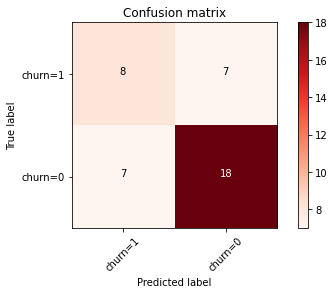

In [34]:
cnf_matrix=confusion_matrix(y_test,yhat,labels=[1,0])
np.set_printoptions(precision=2)

plt.figure()
plot_confusion_matrix(cnf_matrix,classes=['churn=1','churn=0'],normalize=False, title='Confusion matrix')

In [35]:
print (classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72        25
           1       0.53      0.53      0.53        15

    accuracy                           0.65        40
   macro avg       0.63      0.63      0.63        40
weighted avg       0.65      0.65      0.65        40



<h3>3- log loss</h3>

In [36]:
from sklearn.metrics import log_loss
log_loss(y_test,yhat_prob)

0.6155809757244557

<h2 id="practice">Practice</h2>
Try to build Logistic Regression model again for the same dataset, but this time, use different __solver__ and __regularization__ values? What is new __logLoss__ value?

In [37]:
model2 = LogisticRegression(C=0.01, solver='sag').fit(x_train,y_train)
# Logistic Regression supports these solvers ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
yhat_prob2 = model2.predict_proba(x_test)
print ("LogLoss: : %.2f" % log_loss(y_test, yhat_prob2))

LogLoss: : 0.62


In [38]:
yhat=model2.predict(x_test)

confusion matrix,without normalization
[[ 0 15]
 [ 0 25]]


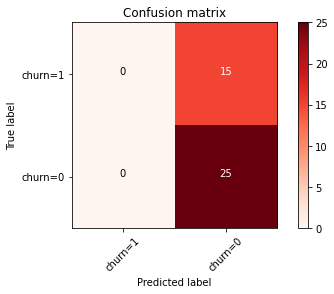

In [39]:
cnf_matrix=confusion_matrix(y_test,yhat,labels=[1,0])
np.set_printoptions(precision=2)

plt.figure()
plot_confusion_matrix(cnf_matrix,classes=['churn=1','churn=0'],normalize=False, title='Confusion matrix')

In [40]:
print (classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.62      1.00      0.77        25
           1       0.00      0.00      0.00        15

    accuracy                           0.62        40
   macro avg       0.31      0.50      0.38        40
weighted avg       0.39      0.62      0.48        40



C:\Users\bgc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\bgc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\bgc\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
